### In this notebook we demonstrate the curve fitting capabilities using simulated data on a basic model.

Note that with a fitted model, the Tru-T code is a little more "ready-to-go" (e.g. see the README where we use the commandline interface). However, below we use lower-level functionality to both find an equilibrium solution for a system with known fitting parameters as well as perform a curve fit on simulated data. In the end, we show that the curve fitting routines are able to more or less recover the features of the simulated experimental data

In [1]:
# typical imports for table reading/manipulation and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import curve_fit

# our modeling framework
from src.model_factories import JsonModelFactory
from src.model_solvers import ODESolverWJacobian
from src.batch_process import calculate

/Users/Brian/xyone/tru-t/application/src/parsers.py:32: SyntaxWarning: invalid escape sequence '\+'
  equation_regex = re.compile('[a-zA-Z0-9\+\s\*]+')


### To specify the system we wish to study, models are described in JSON syntax. 

Here we define a sequential binding system where species S has two binding sites for T. We have unbound S and unbound T, as well as the single-bound complex "ST" and double-bound complex "ST2". Thus, we have a total of 4 species present in this system.

In the model specification below, note that we need to define the required initial conditions in `"required_initial_conditions"`. As with most dynamical systems, we have governing equations, but need to know the starting state from which we evolve. In our simple system, we obviously need to know the *total* amount of S and T which are present. Technically, the initial conditions *could* be given in terms of the 4 potential species S, T, ST, and ST2. However, since our interest here is *not* in the transient states prior to equilibrium, it is simplest to assume that at t=0 we have the total T and total S all in unbound state. This is what `"required_initial_conditions":["S","T"]` specifies.

Note that the modeling software is not "smart enough" to look at the reactions and determine whether the model is truly sensible. Often, our choice for `"required_initial_conditions"` is dictated by the experimental setup (e.g. a fixed amount of total T and increasing amounts of total S). So ultimately we require a human to make this judgement. 

In [2]:
# a JSON string dictating the system.
model_json = '''
{
    "reactions":[
        {
            "reaction_expression": "S + T <-> ST",
            "fwd_k": 10,
            "rev_k": 28
        },
        {
            "reaction_expression": "ST + T <-> ST2",
            "fwd_k": 13,
            "rev_k": 9
        }

    ],
    "required_initial_conditions":["S","T"]
}
'''

# write the string to a file since the `JsonModelFactory` class below expects a file path as an input:
with open('model_file.json', 'w') as fout:
    fout.write(model_json)

# Read the model and define a solver:
model = JsonModelFactory('model_file.json').get_model()
solver = ODESolverWJacobian(model)

Now we define the initial concentrations of S and T. Note that the initial conditions here *must match* those defined above in the `"required_initial_conditions"` field of the JSON model specification.

We then use the solver above to run the iterations for a dimensionless time of 20; this time typically does not matter much as long as it is large enough to permit convergence. We will double-check the time history to confirm. 

In [3]:
ic = {
    'S': 1.5,
    'T': 10
}

# This runs the iterative algorithm for a dimensionless time of t=20.
species_to_col_mapping, solution, t = solver.equilibrium_solution(ic, 20)

Note that `solution` is a matrix with N rows (corresponding to the discrete time steps) and k=4 columns (corresponding to the four species present: S,T,ST,ST2). The   `species_to_col_mapping` tells us which columns corresponding to which species (e.g. given `{'S': 0, 'ST': 1, 'ST2': 2, 'T': 3}` then the single-bound state "ST" is found in column 1 - the second column of the matrix since everything is zero indexed).

Show the time history of the solution process:

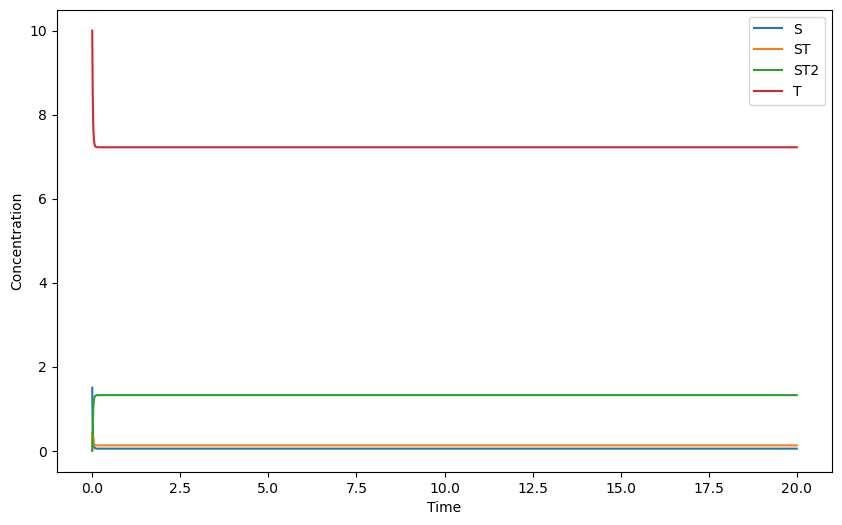

In [4]:
fig, ax = plt.subplots(figsize=(10,6))

for species,idx in species_to_col_mapping.items():
    vals = solution[:, idx]
    ax.plot(t, vals, label=species)

ax.set_xlabel('Time')
ax.set_ylabel('Concentration')
ax.legend()
plt.show()
plt.close()

Clearly this has converged and t=20 was more than adequate. Generally, solving for equilibrium is very fast so there's no huge need to shorten that duration.

### Now that we've seen how to solve for equilibrium concentrations in a system with known rate constants, we create some simulated data to demonstrate the curve-fitting algorithm. 

In practice, we generate experimental data and propose a potential model of the system. We will then use the curve fitting algorithm to optimize the rate constant parameters and (hopefully) arrive at a model that adequately predicts the equilbrium concentrations we are measuring.

Below, we mock an experiment where we fix the total T and measure the equilibrium concentrations given total S ranging from 0 to 20 (arbitrary units)

In [5]:
# create a simulated curve. Here we sample 100 values of total S between 0 and 20. We fix the total T to 10
total_S_vals = np.linspace(0,20, num=100)
total_T = 10.0

# below, we use our existing model (defined above) to generate simulated values. 
# We then add some noise
simulated_data = []
for S in total_S_vals:
    ic = {
        'S': S,
        'T': total_T
    }
    species_to_col_mapping, solution, t = solver.equilibrium_solution(ic, 20)

    # Take the equilibrium solution as the final time point in our iterative solution
    final_solution = solution[-1,:]
    
    # extract the values 
    st_val = final_solution[species_to_col_mapping['ST']]
    st2_val = final_solution[species_to_col_mapping['ST2']]
    free_t_val = final_solution[species_to_col_mapping['T']]
    free_s_val = final_solution[species_to_col_mapping['S']]
    
    # bound T comes from ST + ST2. The first compound has a single T while the second has two.
    bound_t = st_val + 2*st2_val + np.random.normal(scale=0.1)  # <--- note that we are adding random noise here
    simulated_data.append(
        pd.Series({
            'total_S': S,
            'free_T': free_t_val,
            'bound_T': bound_t,
            'bound_S': st_val + st2_val,
            'free_S': free_s_val,
            'total_T': free_t_val + bound_t
        })
    )
simulated_data = pd.DataFrame(simulated_data)
simulated_data

,total_S,free_T,bound_T,bound_S,free_S,total_T
0,0.000000,10.000000,0.321434,0.000000,0.000000,10.321434
1,0.202020,9.617014,0.608285,0.198146,0.003874,10.225299
2,0.404040,9.236237,0.907870,0.395676,0.008364,10.144107
3,0.606061,8.857981,1.127855,0.592484,0.013576,9.985836
4,0.808081,8.482607,1.391797,0.788443,0.019638,9.874405
...,...,...,...,...,...,...
95,19.191919,0.679593,9.265892,6.232861,12.959058,9.945484
96,19.393939,0.673928,9.233210,6.245388,13.148551,9.907138
97,19.595960,0.668378,9.399939,6.257766,13.338193,10.068316
98,19.797980,0.662939,9.483063,6.269999,13.527981,10.146002


Plot the mock data-

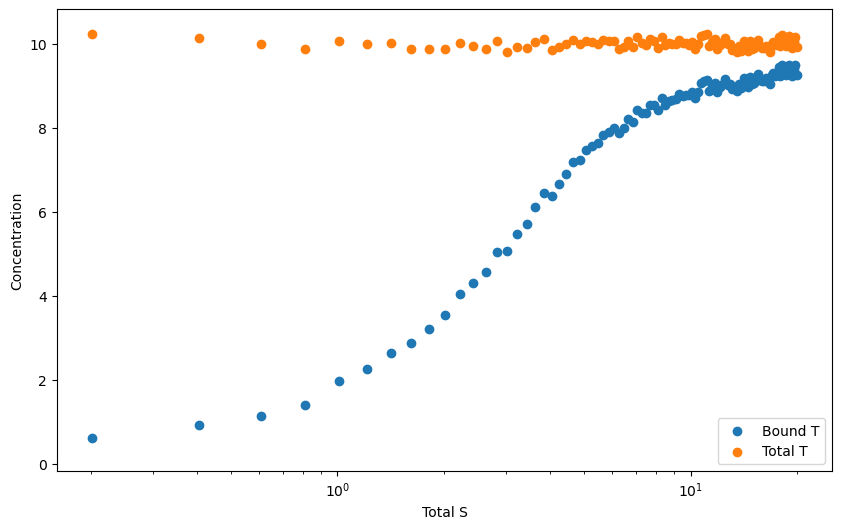

In [6]:
fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(simulated_data['total_S'], simulated_data['bound_T'], label='Bound T')
ax.scatter(simulated_data['total_S'], simulated_data['bound_T']+simulated_data['free_T'], label='Total T')
ax.set_xlabel('Total S')
ax.set_ylabel('Concentration')
ax.semilogx()
ax.legend()
plt.show()
plt.close()

### Now attempt a curve fit - ideally, we will recover the same rate constants we used when creating the simulated data

The `curve_fit` function in SciPy requires a "callable" (i.e. a function) that takes an array of current values and returns the objective we are looking to minimize. In our situation, we are looking to fit the curve above where we plotted the bound T values. Hence, the function should take the input values (total S, total T) and return the bound T given the current values of the rate constant parameters. The `curve_fit` function will iteratively adjust those rate constants to minimize the squared error between the "actual" bound T and the bound T calculated using the current guess for those rate constant parameters.

In [7]:
def fit_func(x, *args):
    '''
    x is a numpy array with the total S and total T
    *args has the rate parameters which are being adjusted in an attempt
      to minimize the squared error
    '''
    bound_vals = []
    for i in range(x.shape[1]):
        total_S = x[0,i]
        total_T = x[1,i]
        ic = {
            'S': total_S,
            'T': total_T
        }
        # need to cast the rate constants as a numpy array
        k = np.array(args)

        # given the current rate constants in k, get the equilibrium concentrations
        species_to_col_mapping, solution, t = solver.equilibrium_solution(ic, 20, k=k)

        # the equilibrium state:
        final_solution = solution[-1,:]

        # calculate the bound T
        st_val = final_solution[species_to_col_mapping['ST']]
        st2_val = final_solution[species_to_col_mapping['ST2']]
        _bt = st_val + 2*st2_val
        bound_vals.append(_bt)
    return np.array(bound_vals)

In [8]:
# the model (e.g. the JSON from above) expects initial conditions dictating S and T.  total S and total T (by design means ST and ST2 are both zero). Thus, we want total S and total T
data = simulated_data[['total_S','total_T']].values.T

# fit the curve. Note that we provide an initial guess for the rate constants with the p0 arg:
popt, pcov = curve_fit(fit_func, data, simulated_data['bound_T'].values, p0=np.array([1,1,1,1]))

/Users/Brian/xyone/tru-t/application/src/model_solvers.py:335: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  X = integrate.odeint(


 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1220286718560D-01   r2 =  0.7066976082351D-18
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1220286718560D-01   r2 =  0.7066976082351D-18
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.7120087807452D-01   r2 =  0.6230509820547D-17
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.7120087807452D-01   r2 =  0.6230509820547D-17
 lsoda--  warning..internal t (=r1) 

Now that we have an optimal set of parameters (hopefully!...assuming convergence), calculate the equilibrium values. We can then plot those values against our "experimental" (simulated) data 

In [9]:
# Using the optimal rate constants determined above, calculate the equilibrium concentration for total S values ranging from 0 to 20
# while keeping total T fixed at 10.
total_S_vals = np.linspace(0,20, num=100)
total_T = 10.0

fitted_data = []
for S in total_S_vals:
    ic = {
        'S': S,
        'T': total_T
    }
    species_to_col_mapping, solution, t = solver.equilibrium_solution(ic, 20, k=popt)
    final_solution = solution[-1,:]
    # bound T comes from ST + ST2. The first compound has a single T while the second has two.
    st_val = final_solution[species_to_col_mapping['ST']]
    st2_val = final_solution[species_to_col_mapping['ST2']]
    free_t_val = final_solution[species_to_col_mapping['T']]
    free_s_val = final_solution[species_to_col_mapping['S']]
    _bt = st_val + 2*st2_val
    fitted_data.append(
        pd.Series({
            'total_S': S,
            'free_T': free_t_val,
            'bound_T': _bt,
            'bound_S': st_val + st2_val,
            'free_S': free_s_val,
            'total_T': free_t_val + _bt
        })
    )
fitted_data = pd.DataFrame(fitted_data)

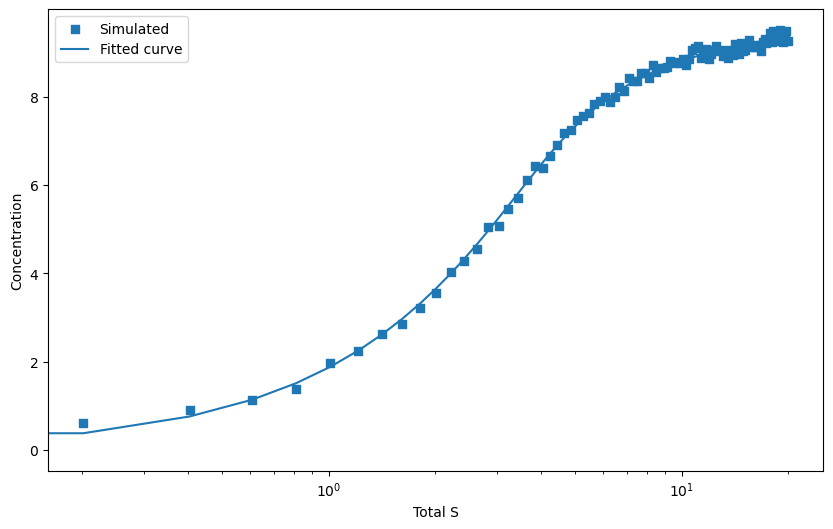

In [10]:
fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(simulated_data['total_S'], simulated_data['bound_T'], marker='s', label='Simulated')
ax.plot(fitted_data['total_S'], fitted_data['bound_T'], label='Fitted curve')
ax.set_xlabel('Total S')
ax.set_ylabel('Concentration')
ax.semilogx()
ax.legend()
plt.show()
plt.close()

### Note that the optimal values do *not* match those of the original model used to create the simulated data. However, the ratios of the reverse and forward rate constants are quite close. 

For example:

In [11]:
popt

array([0.46616953, 0.45870643, 1.19587412, 0.3475164 ])

The rate constants are arranaged such the first half of the array has the forward rate constants and the second half has the reverse rate constants. 

In the original model, the first equation had fwd_k=10 and rev_k=28 for a ratio of 2.8

In [12]:
popt[2]/popt[0]

np.float64(2.5653202194096885)

For the second equation we had fwd_k=13 and rev_k=9 for a ratio of 9/13=0.692

In [13]:
popt[3]/popt[1]

np.float64(0.757600881290693)